# AI-Powered Medical FAQ Semantic Search using Sentence-BERT and FAISS

## Selected Track
**Option A: Semantic Search using Pretrained Embeddings**

---

## Problem Statement

Traditional keyword-based search systems retrieve documents based on exact word matching. However, users often express the same question using different words or sentence structures, causing keyword search to return irrelevant or incomplete results.

For example:

**Dataset Question**
> What are the symptoms of diabetes?

**User Query**
> How do I know if I have diabetes?

Although both questions have the same meaning, keyword search may fail because they use different wording.

This project addresses this limitation by building a semantic search engine using Sentence-BERT embeddings and FAISS. Instead of relying on exact keyword matches, the system understands the semantic meaning of user queries and retrieves the most relevant medical question-answer pairs from the MedQuAD dataset.

---

## Objectives

- Build a semantic search engine for medical FAQs.
- Generate sentence embeddings using a pretrained Sentence-BERT model.
- Store embeddings efficiently using FAISS.
- Retrieve the most relevant medical answers using cosine similarity.
- Compare semantic search with traditional keyword search.
- Evaluate the system using multiple user queries.

---

## Technologies Used

- Python
- Google Colab
- Pandas
- NumPy
- Sentence Transformers
- FAISS
- Scikit-learn
- Matplotlib

# Step 1: Install Required Libraries


In [1]:
!pip -q install sentence-transformers faiss-cpu kagglehub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 90.6 MB/s eta 0:00:00


# Step 2: Import Required Libraries


In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import faiss
import kagglehub

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

# Step 3: Download the MedQuAD Dataset


In [4]:
# Download latest version

dataset_path = kagglehub.dataset_download(
    "pythonafroz/medquad-medical-question-answer-for-ai-research"
)

print("Dataset downloaded to:")
print(dataset_path)

100%|██████████| 4.95M/4.95M [00:00<00:00, 80.2MB/s]

Extracting files...


Dataset downloaded to:
/root/.cache/kagglehub/datasets/pythonafroz/medquad-medical-question-answer-for-ai-research/versions/1


# Step 4: Explore the Downloaded Dataset


In [5]:
import os

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        print(os.path.join(root, file))

/root/.cache/kagglehub/datasets/pythonafroz/medquad-medical-question-answer-for-ai-research/versions/1/medquad.csv


# Step 5: Load the Dataset


In [6]:
# Path to the CSV file
csv_path = os.path.join(dataset_path, "medquad.csv")

# Load dataset
df = pd.read_csv(csv_path)

# Display first 5 rows
df.head()

,question,answer,source,focus_area
0,What is (are) Glaucoma ?,Glaucoma is a group of diseases that can damag...,NIHSeniorHealth,Glaucoma
1,What causes Glaucoma ?,"Nearly 2.7 million people have glaucoma, a lea...",NIHSeniorHealth,Glaucoma
2,What are the symptoms of Glaucoma ?,Symptoms of Glaucoma Glaucoma can develop in ...,NIHSeniorHealth,Glaucoma
3,What are the treatments for Glaucoma ?,"Although open-angle glaucoma cannot be cured, ...",NIHSeniorHealth,Glaucoma
4,What is (are) Glaucoma ?,Glaucoma is a group of diseases that can damag...,NIHSeniorHealth,Glaucoma


# Step 6: Explore the Dataset


In [7]:
print(f"Dataset Shape: {df.shape}")
print("\nColumns:")
print(df.columns.tolist())

Dataset Shape: (16412, 4)

Columns:
['question', 'answer', 'source', 'focus_area']


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16412 entries, 0 to 16411
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   question    16412 non-null  object
 1   answer      16407 non-null  object
 2   source      16412 non-null  object
 3   focus_area  16398 non-null  object
dtypes: object(4)
memory usage: 513.0+ KB


In [9]:
df.isnull().sum()

,0
question,0
answer,5
source,0
focus_area,14


In [10]:
df.sample(5)

,question,answer,source,focus_area
4493,What is (are) Myelodysplastic/myeloproliferati...,Myelodysplastic/myeloproliferative diseases ar...,GARD,Myelodysplastic/myeloproliferative disease
13687,What are the genetic changes related to DICER1...,DICER1 syndrome is caused by mutations in the ...,GHR,DICER1 syndrome
13120,What is (are) Vohwinkel syndrome ?,Vohwinkel syndrome is a disorder with classic ...,GHR,Vohwinkel syndrome
8909,what research (or clinical trials) is being do...,"The National Institutes of Health (NIH), and t...",NINDS,Williams Syndrome
823,What is the outlook for Childhood Soft Tissue ...,Certain factors affect prognosis (chance of re...,CancerGov,Childhood Soft Tissue Sarcoma


# Step 7: Data Cleaning and Preprocessing


In [11]:
# Create a copy so the original dataset remains unchanged
clean_df = df.copy()

# Remove rows with missing questions or answers
clean_df = clean_df.dropna(subset=["question", "answer"])

# Remove duplicate question-answer pairs
clean_df = clean_df.drop_duplicates(subset=["question", "answer"])

# Clean whitespace
clean_df["question"] = clean_df["question"].str.strip()
clean_df["answer"] = clean_df["answer"].str.strip()

# Reset index
clean_df = clean_df.reset_index(drop=True)

print("Original dataset size:", len(df))
print("Cleaned dataset size:", len(clean_df))
print("Rows removed:", len(df) - len(clean_df))

Original dataset size: 16412
Cleaned dataset size: 16359
Rows removed: 53


In [12]:
# Check missing values
print("Missing values after cleaning:")
print(clean_df[["question", "answer"]].isnull().sum())

print("\nCleaned dataset shape:", clean_df.shape)

# Display sample records
clean_df.sample(5, random_state=42)

Missing values after cleaning:
question    0
answer      0
dtype: int64

Cleaned dataset shape: (16359, 4)


,question,answer,source,focus_area
2858,Is Galactosialidosis inherited ?,How is galactosialidosis inherited? Galactosia...,GARD,Galactosialidosis
11208,"Is 17 alpha-hydroxylase/17,20-lyase deficiency...",This condition is inherited in an autosomal re...,GHR,"17 alpha-hydroxylase/17,20-lyase deficiency"
7731,What are the symptoms of Idiopathic inflammato...,What are the signs and symptoms of Idiopathic ...,GARD,Idiopathic inflammatory myopathy
4948,What are the symptoms of 8p23.1 duplication sy...,What are the signs and symptoms of 8p23.1 dupl...,GARD,8p23.1 duplication syndrome
733,What are the treatments for Gum (Periodontal) ...,Controlling the Infection The main goal of tre...,NIHSeniorHealth,Gum (Periodontal) Disease


In [13]:
# Number of unique sources
print("Number of unique sources:", clean_df["source"].nunique())

# Top sources
print("\nQuestions by source:")
print(clean_df["source"].value_counts())

Number of unique sources: 9

Questions by source:
source
GHR                  5430
GARD                 5389
NIDDK                1144
NINDS                1088
MPlusHealthTopics     981
NIHSeniorHealth       769
CancerGov             729
NHLBI                 559
CDC                   270
Name: count, dtype: int64


In [14]:
# Number of unique medical topics
print("Number of unique focus areas:", clean_df["focus_area"].nunique())

# Top 15 focus areas
print("\nTop 15 focus areas:")
print(clean_df["focus_area"].value_counts().head(15))

Number of unique focus areas: 5125

Top 15 focus areas:
focus_area
Breast Cancer             53
Prostate Cancer           43
Stroke                    35
Skin Cancer               34
Alzheimer's Disease       30
Colorectal Cancer         29
Lung Cancer               29
Heart Failure             28
High Blood Cholesterol    28
Heart Attack              28
High Blood Pressure       27
Parkinson's Disease       25
Leukemia                  22
Shingles                  21
Osteoporosis              21
Name: count, dtype: int64


## Distribution of Questions by Source


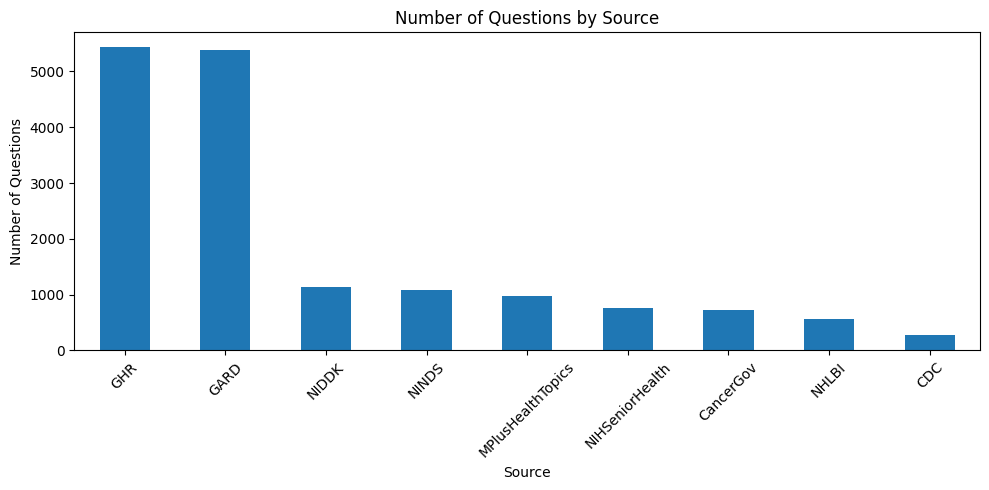

In [15]:
source_counts = clean_df["source"].value_counts()

plt.figure(figsize=(10, 5))
source_counts.plot(kind="bar")

plt.title("Number of Questions by Source")
plt.xlabel("Source")
plt.ylabel("Number of Questions")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## Most Common Medical Focus Areas


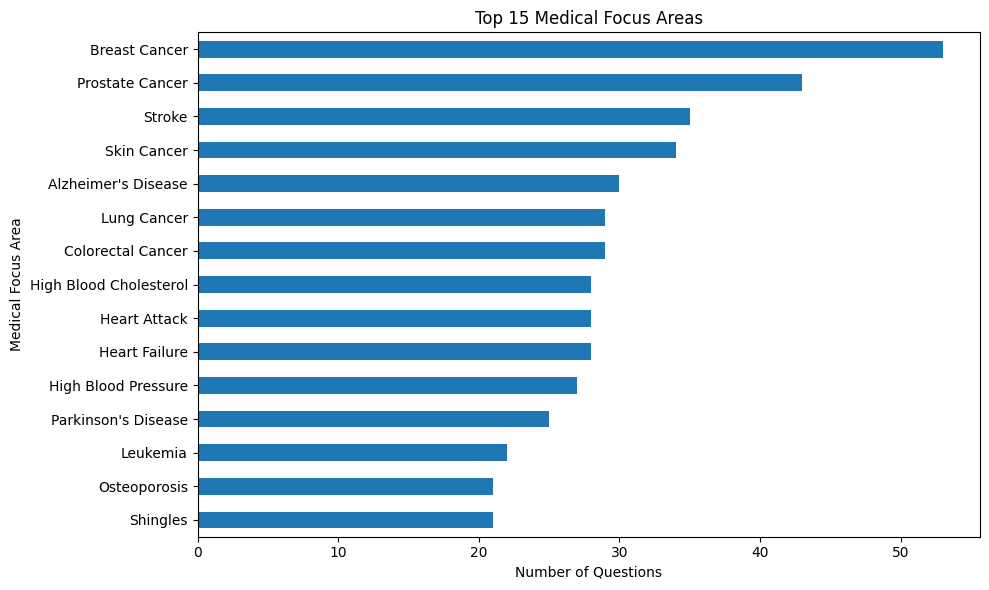

In [16]:
top_topics = clean_df["focus_area"].value_counts().head(15)

plt.figure(figsize=(10, 6))
top_topics.sort_values().plot(kind="barh")

plt.title("Top 15 Medical Focus Areas")
plt.xlabel("Number of Questions")
plt.ylabel("Medical Focus Area")

plt.tight_layout()
plt.show()

# Step 12: Load the Pretrained Sentence-BERT Model
**`all-MiniLM-L6-v2`**


In [17]:
# Load the pretrained Sentence-BERT model
model = SentenceTransformer("all-MiniLM-L6-v2")

print("Model loaded successfully.")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded successfully.


# Step 14: Generate Sentence Embeddings

Each question is represented by a 384-dimensional vector.

In [18]:
# Extract questions
questions = clean_df["question"].tolist()

# Generate embeddings
embeddings = model.encode(
    questions,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

print("Embedding shape:", embeddings.shape)

Batches:   0%|          | 0/512 [00:00<?, ?it/s]

Embedding shape: (16359, 384)


In [19]:
# Display the first question and its embedding
print("Question:")
print(questions[0])

print("\nEmbedding dimensions:")
print(len(embeddings[0]))

print("\nFirst 10 embedding values:")
print(embeddings[0][:10])

Question:
What is (are) Glaucoma ?

Embedding dimensions:
384

First 10 embedding values:
[ 0.02821385 -0.04287186 -0.01605426 -0.00758267 -0.07872254 -0.04315651
  0.09189266  0.02503564  0.02667108  0.06475483]


## Normalize Embeddings for Cosine Similarity

In [20]:
# Normalize embeddings
faiss.normalize_L2(embeddings)

print("Embeddings normalized successfully.")

Embeddings normalized successfully.


In [21]:
## Build the FAISS Vector Index

In [22]:
# Get embedding dimension
embedding_dimension = embeddings.shape[1]

# Create FAISS index using inner product
index = faiss.IndexFlatIP(embedding_dimension)

# Add embeddings to the index
index.add(embeddings)

print("FAISS index created successfully.")
print("Number of vectors in index:", index.ntotal)

FAISS index created successfully.
Number of vectors in index: 16359


## Implement Semantic Search


In [23]:
def semantic_search(query, top_k=5):
    """
    Search the MedQuAD dataset using semantic similarity.

    Parameters:
        query (str): User's medical question.
        top_k (int): Number of results to retrieve.

    Returns:
        pandas.DataFrame: Top-k semantically similar results.
    """

    # Convert query into an embedding
    query_embedding = model.encode(
        [query],
        convert_to_numpy=True
    )

    # Normalize query embedding
    faiss.normalize_L2(query_embedding)

    # Search FAISS index
    scores, indices = index.search(query_embedding, top_k)

    # Retrieve matching records
    results = clean_df.iloc[indices[0]].copy()

    # Add similarity scores
    results["similarity_score"] = scores[0]

    # Reset index
    results = results.reset_index(drop=True)

    return results

## Test Semantic Search


In [24]:
query = "How can I tell if I have high blood pressure?"

results = semantic_search(query, top_k=5)

results[[
    "question",
    "answer",
    "focus_area",
    "source",
    "similarity_score"
]]

,question,answer,focus_area,source,similarity_score
0,How to diagnose High Blood Pressure ?,"If you are diagnosed with high blood pressure,...",High Blood Pressure,NIHSeniorHealth,0.887597
1,How to diagnose High Blood Pressure ?,"For most patients, health care providers diagn...",High Blood Pressure,NHLBI,0.887597
2,What are the symptoms of High Blood Pressure ?,Because diagnosis is based on blood pressure r...,High Blood Pressure,NHLBI,0.864132
3,What are the symptoms of High Blood Pressure ?,"High blood pressure is often called the ""silen...",High Blood Pressure,NIHSeniorHealth,0.864132
4,What are the symptoms of High Blood Pressure a...,Most people with high blood pressure do not ha...,High Blood Pressure and Kidney Disease,NIDDK,0.752344


In [26]:
def display_results(query, top_k=5):
    results = semantic_search(query, top_k)

    print(f"Query: {query}")
    print("=" * 100)

    for i, row in results.iterrows():
        print(f"\nResult {i + 1}")
        print(f"Similarity Score: {row['similarity_score']:.4f}")
        print(f"Focus Area: {row['focus_area']}")
        print(f"Source: {row['source']}")
        print(f"Question: {row['question']}")
        print(f"Answer: {row['answer']}")
        print("-" * 100)

In [27]:
display_results(
    "How can I tell if I have high blood pressure?",
    top_k=5
)

Query: How can I tell if I have high blood pressure?

Result 1
Similarity Score: 0.8876
Focus Area: High Blood Pressure
Source: NIHSeniorHealth
Question: How to diagnose High Blood Pressure ?
Answer: If you are diagnosed with high blood pressure, here are questions to ask your doctor. -   Your Blood Pressure Numbers       - What is my blood pressure reading in numbers?    - What is my goal blood pressure?    - Is my blood pressure under adequate control?    - Is my systolic pressure too high (over 140)?      Your Blood Pressure Numbers     - What is my blood pressure reading in numbers?   - What is my goal blood pressure?   - Is my blood pressure under adequate control?   - Is my systolic pressure too high (over 140)?   - What is my blood pressure reading in numbers?  - What is my goal blood pressure?  - Is my blood pressure under adequate control?  - Is my systolic pressure too high (over 140)? What is my blood pressure reading in numbers? What is my goal blood pressure? Is my blood p

In [28]:
display_results(
    "What are the symptoms and treatment options for breast cancer?",
    top_k=5
)

Query: What are the symptoms and treatment options for breast cancer?

Result 1
Similarity Score: 0.8817
Focus Area: Breast Cancer
Source: NIHSeniorHealth
Question: What are the treatments for Breast Cancer ?
Answer: Standard treatments for breast cancer include - surgery that takes out the cancer and some surrounding tissue  - radiation therapy that uses high-energy beams to kill cancer cells and shrink tumors and some surrounding tissue.  - chemotherapy that uses anti-cancer drugs to kill cancer most cells  - hormone therapy that keeps cancer cells from getting most of the hormones they need to survive and grow. surgery that takes out the cancer and some surrounding tissue radiation therapy that uses high-energy beams to kill cancer cells and shrink tumors and some surrounding tissue. chemotherapy that uses anti-cancer drugs to kill cancer most cells hormone therapy that keeps cancer cells from getting most of the hormones they need to survive and grow. (Watch the video to learn abou

In [29]:
display_results(
    "What causes Parkinson's disease?",
    top_k=5
)

Query: What causes Parkinson's disease?

Result 1
Similarity Score: 1.0000
Focus Area: Parkinson's Disease
Source: NIHSeniorHealth
Question: What causes Parkinson's Disease ?
Answer: Parkinson's disease occurs when nerve cells, or neurons, in an area of the brain that controls movement die or become impaired. Normally, these neurons produce an important brain chemical known as dopamine, but once the neurons become impaired, they produce less dopamine and eventually die. It is this shortage of dopamine that causes the movement problems of people with Parkinson's.
----------------------------------------------------------------------------------------------------

Result 2
Similarity Score: 1.0000
Focus Area: Parkinson's Disease
Source: NIHSeniorHealth
Question: What causes Parkinson's Disease ?
Answer: A Shortage of Dopamine Parkinson's disease occurs when nerve cells, or neurons, in an area of the brain that controls movement become impaired and/or die. Normally, these neurons produce 

Demonstrating Semantic Understanding

In [30]:
queries = [
    "How can I tell if I have high blood pressure?",
    "What are the signs of hypertension?",
    "How do I know whether my blood pressure is too high?"
]

for q in queries:
    results = semantic_search(q, top_k=1)

    print("\nQuery:", q)
    print("Retrieved:", results.iloc[0]["question"])
    print("Focus Area:", results.iloc[0]["focus_area"])
    print("Similarity:", round(results.iloc[0]["similarity_score"], 4))


Query: How can I tell if I have high blood pressure?
Retrieved: How to diagnose High Blood Pressure ?
Focus Area: High Blood Pressure
Similarity: 0.8876

Query: What are the signs of hypertension?
Retrieved: What are the symptoms of High Blood Pressure ?
Focus Area: High Blood Pressure
Similarity: 0.8379

Query: How do I know whether my blood pressure is too high?
Retrieved: How to diagnose High Blood Pressure ?
Focus Area: High Blood Pressure
Similarity: 0.8407


In [31]:
evaluation_queries = [
    {
        "query": "What are the signs and symptoms of high blood pressure?",
        "expected_focus": "High Blood Pressure"
    },
    {
        "query": "How can diabetes be diagnosed?",
        "expected_focus": "Diabetes"
    },
    {
        "query": "What are the symptoms of breast cancer?",
        "expected_focus": "Breast Cancer"
    },
    {
        "query": "What causes Parkinson's disease?",
        "expected_focus": "Parkinson's Disease"
    },
    {
        "query": "What are the symptoms of a heart attack?",
        "expected_focus": "Heart Attack"
    },
    {
        "query": "How can I recognize the symptoms of a stroke?",
        "expected_focus": "Stroke"
    },
    {
        "query": "What are the signs of Alzheimer's disease?",
        "expected_focus": "Alzheimer's Disease"
    },
    {
        "query": "What are the symptoms of lung cancer?",
        "expected_focus": "Lung Cancer"
    },
    {
        "query": "How is high cholesterol treated?",
        "expected_focus": "High Blood Cholesterol"
    },
    {
        "query": "What are the symptoms of osteoporosis?",
        "expected_focus": "Osteoporosis"
    },
    {
        "query": "What are the symptoms of leukemia?",
        "expected_focus": "Leukemia"
    },
    {
        "query": "What are the symptoms of shingles?",
        "expected_focus": "Shingles"
    }
]

print("Number of evaluation queries:", len(evaluation_queries))

Number of evaluation queries: 12


In [32]:
evaluation_results = []

for item in evaluation_queries:

    query = item["query"]
    expected_focus = item["expected_focus"]

    results = semantic_search(query, top_k=5)

    retrieved_focus_areas = results["focus_area"].fillna("").tolist()

    # Check whether expected focus appears in Top-5
    top5_match = expected_focus in retrieved_focus_areas

    # Top-1 match
    top1_match = retrieved_focus_areas[0] == expected_focus

    evaluation_results.append({
        "query": query,
        "expected_focus": expected_focus,
        "top1_focus": retrieved_focus_areas[0],
        "top5_focus_areas": retrieved_focus_areas,
        "top1_match": top1_match,
        "top5_match": top5_match
    })

evaluation_df = pd.DataFrame(evaluation_results)

evaluation_df

,query,expected_focus,top1_focus,top5_focus_areas,top1_match,top5_match
0,What are the signs and symptoms of high blood ...,High Blood Pressure,High Blood Pressure,"[High Blood Pressure, High Blood Pressure, Hig...",True,True
1,How can diabetes be diagnosed?,Diabetes,Diagnosis of Diabetes and Prediabetes,"[Diagnosis of Diabetes and Prediabetes, Diagno...",False,False
2,What are the symptoms of breast cancer?,Breast Cancer,Breast Cancer,"[Breast Cancer, Breast Cancer, Breast Cancer, ...",True,True
3,What causes Parkinson's disease?,Parkinson's Disease,Parkinson's Disease,"[Parkinson's Disease, Parkinson's Disease, Par...",True,True
4,What are the symptoms of a heart attack?,Heart Attack,Heart Attack,"[Heart Attack, Heart Attack, Heart Attack, Hea...",True,True
5,How can I recognize the symptoms of a stroke?,Stroke,Stroke,"[Stroke, Stroke, Stroke, Stroke, Stroke]",True,True
6,What are the signs of Alzheimer's disease?,Alzheimer's Disease,Alzheimer's Disease,"[Alzheimer's Disease, Alzheimer's Disease, Alz...",True,True
7,What are the symptoms of lung cancer?,Lung Cancer,Lung Cancer,"[Lung Cancer, Lung Cancer, Lung adenocarcinoma...",True,True
8,How is high cholesterol treated?,High Blood Cholesterol,High Blood Cholesterol,"[High Blood Cholesterol, High Blood Cholestero...",True,True
9,What are the symptoms of osteoporosis?,Osteoporosis,Osteoporosis,"[Osteoporosis, Osteoporosis, Juvenile osteopor...",True,True


## Top-1 Accuracy


In [33]:
top1_accuracy = evaluation_df["top1_match"].mean()

print(f"Top-1 Accuracy: {top1_accuracy:.2%}")

Top-1 Accuracy: 91.67%


## Top-5 Accuracy

In [34]:
top5_accuracy = evaluation_df["top5_match"].mean()

print(f"Top-5 Accuracy: {top5_accuracy:.2%}")

Top-5 Accuracy: 91.67%


## Mean Reciprocal Rank (MRR)

In [36]:
def calculate_reciprocal_rank(query, expected_focus, top_k=5):

    results = semantic_search(query, top_k=top_k)

    focus_areas = results["focus_area"].fillna("").tolist()

    for rank, focus in enumerate(focus_areas, start=1):
        if focus == expected_focus:
            return 1 / rank

    return 0


reciprocal_ranks = []

for item in evaluation_queries:
    rr = calculate_reciprocal_rank(
        item["query"],
        item["expected_focus"],
        top_k=5
    )

    reciprocal_ranks.append(rr)


mrr = np.mean(reciprocal_ranks)

print(f"Mean Reciprocal Rank (MRR): {mrr:.4f}")

Mean Reciprocal Rank (MRR): 0.9167


In [37]:
evaluation_summary = pd.DataFrame({
    "Metric": [
        "Top-1 Accuracy",
        "Top-5 Accuracy",
        "Mean Reciprocal Rank (MRR)"
    ],
    "Score": [
        f"{top1_accuracy:.2%}",
        f"{top5_accuracy:.2%}",
        f"{mrr:.4f}"
    ]
})

evaluation_summary

,Metric,Score
0,Top-1 Accuracy,91.67%
1,Top-5 Accuracy,91.67%
2,Mean Reciprocal Rank (MRR),0.9167


Check Evaluation Query Similarity

In [38]:
# Check how similar each evaluation query is to the retrieved dataset question

for item in evaluation_queries:

    query = item["query"]

    results = semantic_search(query, top_k=1)

    retrieved_question = results.iloc[0]["question"]
    score = results.iloc[0]["similarity_score"]

    print("\nQuery:")
    print(query)

    print("\nRetrieved dataset question:")
    print(retrieved_question)

    print("\nSimilarity:")
    print(round(score, 4))

    print("-" * 100)


Query:
What are the signs and symptoms of high blood pressure?

Retrieved dataset question:
What are the symptoms of High Blood Pressure ?

Similarity:
0.9856
----------------------------------------------------------------------------------------------------

Query:
How can diabetes be diagnosed?

Retrieved dataset question:
What is (are) Diagnosis of Diabetes and Prediabetes ?

Similarity:
0.7938
----------------------------------------------------------------------------------------------------

Query:
What are the symptoms of breast cancer?

Retrieved dataset question:
What are the symptoms of Breast Cancer ?

Similarity:
1.0
----------------------------------------------------------------------------------------------------

Query:
What causes Parkinson's disease?

Retrieved dataset question:
What causes Parkinson's Disease ?

Similarity:
1.0
----------------------------------------------------------------------------------------------------

Query:
What are the symptoms of a hea

In [40]:
robust_evaluation_queries = [
    {
        "query": "How would someone know that their blood pressure is dangerously high?",
        "expected_focus": "High Blood Pressure"
    },
    {
        "query": "What happens in the body when a person develops diabetes, and how is it identified?",
        "expected_focus": "Diabetes"
    },
    {
        "query": "How might someone notice changes that could indicate breast cancer?",
        "expected_focus": "Breast Cancer"
    },
    {
        "query": "Why does Parkinson's develop and what changes does it cause in the body?",
        "expected_focus": "Parkinson's Disease"
    },
    {
        "query": "How can a person recognize that they might be experiencing a heart attack?",
        "expected_focus": "Heart Attack"
    },
    {
        "query": "What warning signs could tell someone that they are having a stroke?",
        "expected_focus": "Stroke"
    },
    {
        "query": "How might a person realize that they could be developing Alzheimer's?",
        "expected_focus": "Alzheimer's Disease"
    },
    {
        "query": "What changes might occur in someone who develops cancer in the lungs?",
        "expected_focus": "Lung Cancer"
    },
    {
        "query": "What can be done to manage unhealthy levels of cholesterol?",
        "expected_focus": "High Blood Cholesterol"
    },
    {
        "query": "How might someone notice that their bones have become unusually weak?",
        "expected_focus": "Osteoporosis"
    },
    {
        "query": "What changes might suggest that someone has developed leukemia?",
        "expected_focus": "Leukemia"
    },
    {
        "query": "How does shingles usually appear or feel when someone develops it?",
        "expected_focus": "Shingles"
    },
    {
        "query": "What can lead to problems with the heart becoming unable to pump blood effectively?",
        "expected_focus": "Heart Failure"
    },
    {
        "query": "How can someone determine whether they may have excessively high cholesterol?",
        "expected_focus": "High Blood Cholesterol"
    },
    {
        "query": "What kinds of problems can occur when someone has a heart attack?",
        "expected_focus": "Heart Attack"
    },
    {
        "query": "What might indicate that a person is developing a serious problem with their blood pressure?",
        "expected_focus": "High Blood Pressure"
    },
    {
        "query": "What could explain changes in movement and coordination associated with Parkinson's?",
        "expected_focus": "Parkinson's Disease"
    },
    {
        "query": "What physical changes can occur when cancer affects the lungs?",
        "expected_focus": "Lung Cancer"
    },
    {
        "query": "How might a person discover that they have unusually fragile bones?",
        "expected_focus": "Osteoporosis"
    },
    {
        "query": "What warning signs could suggest that someone may have developed breast cancer?",
        "expected_focus": "Breast Cancer"
    }
]

print("Number of robust evaluation queries:",
      len(robust_evaluation_queries))

Number of robust evaluation queries: 20


In [41]:
robust_results = []

for item in robust_evaluation_queries:

    query = item["query"]
    expected_focus = item["expected_focus"]

    results = semantic_search(query, top_k=5)

    retrieved_focus = results["focus_area"].fillna("").tolist()

    top1_match = expected_focus == retrieved_focus[0]
    top3_match = expected_focus in retrieved_focus[:3]
    top5_match = expected_focus in retrieved_focus[:5]

    robust_results.append({
        "query": query,
        "expected_focus": expected_focus,
        "top1_focus": retrieved_focus[0],
        "top3_focuses": retrieved_focus[:3],
        "top5_focuses": retrieved_focus[:5],
        "top1_match": top1_match,
        "top3_match": top3_match,
        "top5_match": top5_match
    })

robust_evaluation_df = pd.DataFrame(robust_results)

robust_evaluation_df

,query,expected_focus,top1_focus,top3_focuses,top5_focuses,top1_match,top3_match,top5_match
0,How would someone know that their blood pressu...,High Blood Pressure,High Blood Pressure,"[High Blood Pressure, High Blood Pressure, Hig...","[High Blood Pressure, High Blood Pressure, Hig...",True,True,True
1,What happens in the body when a person develop...,Diabetes,Diabetes,"[Diabetes, Diagnosis of Diabetes and Prediabet...","[Diabetes, Diagnosis of Diabetes and Prediabet...",True,True,True
2,How might someone notice changes that could in...,Breast Cancer,Breast Cancer,"[Breast Cancer, Breast Cancer, Breast Cancer]","[Breast Cancer, Breast Cancer, Breast Cancer, ...",True,True,True
3,Why does Parkinson's develop and what changes ...,Parkinson's Disease,Parkinson's Disease,"[Parkinson's Disease, Parkinson's Disease, Par...","[Parkinson's Disease, Parkinson's Disease, Par...",True,True,True
4,How can a person recognize that they might be ...,Heart Attack,Heart Attack,"[Heart Attack, Heart Attack, Heart Attack]","[Heart Attack, Heart Attack, Heart Attack, Hea...",True,True,True
5,What warning signs could tell someone that the...,Stroke,Stroke,"[Stroke, Stroke, Stroke]","[Stroke, Stroke, Stroke, Stroke, Stroke]",True,True,True
6,How might a person realize that they could be ...,Alzheimer's Disease,Alzheimer's Disease,"[Alzheimer's Disease, Alzheimer's Disease, Alz...","[Alzheimer's Disease, Alzheimer's Disease, Alz...",True,True,True
7,What changes might occur in someone who develo...,Lung Cancer,lung cancer,"[lung cancer, Lung Cancer, Lung Cancer]","[lung cancer, Lung Cancer, Lung Cancer, Lung C...",False,True,True
8,What can be done to manage unhealthy levels of...,High Blood Cholesterol,High Blood Cholesterol,"[High Blood Cholesterol, High Blood Cholestero...","[High Blood Cholesterol, High Blood Cholestero...",True,True,True
9,How might someone notice that their bones have...,Osteoporosis,Osteoporosis,"[Osteoporosis, Osteoporosis, Axial osteomalacia]","[Osteoporosis, Osteoporosis, Axial osteomalaci...",True,True,True


In [42]:
robust_top1 = robust_evaluation_df["top1_match"].mean()
robust_top3 = robust_evaluation_df["top3_match"].mean()
robust_top5 = robust_evaluation_df["top5_match"].mean()

print(f"Robust Top-1 Accuracy: {robust_top1:.2%}")
print(f"Robust Top-3 Accuracy: {robust_top3:.2%}")
print(f"Robust Top-5 Accuracy: {robust_top5:.2%}")

Robust Top-1 Accuracy: 80.00%
Robust Top-3 Accuracy: 95.00%
Robust Top-5 Accuracy: 95.00%


In [43]:
def reciprocal_rank_from_results(results, expected_focus):

    focus_areas = results["focus_area"].fillna("").tolist()

    for rank, focus in enumerate(focus_areas, start=1):
        if focus == expected_focus:
            return 1 / rank

    return 0


robust_rr = []

for item in robust_evaluation_queries:

    results = semantic_search(
        item["query"],
        top_k=5
    )

    rr = reciprocal_rank_from_results(
        results,
        item["expected_focus"]
    )

    robust_rr.append(rr)


robust_mrr = np.mean(robust_rr)

print(f"Robust MRR: {robust_mrr:.4f}")

Robust MRR: 0.8750


## # Error Analysis


In [44]:
# Display Top-1 failures

failed_robust = robust_evaluation_df[
    robust_evaluation_df["top1_match"] == False
]

failed_robust[
    [
        "query",
        "expected_focus",
        "top1_focus",
        "top3_focuses"
    ]
]

,query,expected_focus,top1_focus,top3_focuses
7,What changes might occur in someone who develo...,Lung Cancer,lung cancer,"[lung cancer, Lung Cancer, Lung Cancer]"
10,What changes might suggest that someone has de...,Leukemia,Chronic Myelogenous Leukemia,"[Chronic Myelogenous Leukemia, Leukemia, Leuke..."
17,What physical changes can occur when cancer af...,Lung Cancer,lung cancer,"[lung cancer, Lung Cancer, Lung Cancer]"
18,How might a person discover that they have unu...,Osteoporosis,Spinal muscular atrophy type 1 with congenital...,[Spinal muscular atrophy type 1 with congenita...


In [45]:
def normalize_focus(text):
    if pd.isna(text):
        return ""
    return str(text).strip().lower()

In [46]:
normalized_results = []

for item in robust_evaluation_queries:

    query = item["query"]
    expected_focus = normalize_focus(item["expected_focus"])

    results = semantic_search(query, top_k=5)

    retrieved_focus = [
        normalize_focus(x)
        for x in results["focus_area"]
    ]

    top1_match = expected_focus == retrieved_focus[0]
    top3_match = expected_focus in retrieved_focus[:3]
    top5_match = expected_focus in retrieved_focus[:5]

    normalized_results.append({
        "query": query,
        "expected_focus": expected_focus,
        "top1_focus": retrieved_focus[0],
        "top3_focuses": retrieved_focus[:3],
        "top5_focuses": retrieved_focus[:5],
        "top1_match": top1_match,
        "top3_match": top3_match,
        "top5_match": top5_match
    })

normalized_evaluation_df = pd.DataFrame(normalized_results)

normalized_top1 = normalized_evaluation_df["top1_match"].mean()
normalized_top3 = normalized_evaluation_df["top3_match"].mean()
normalized_top5 = normalized_evaluation_df["top5_match"].mean()

print(f"Normalized Top-1 Accuracy: {normalized_top1:.2%}")
print(f"Normalized Top-3 Accuracy: {normalized_top3:.2%}")
print(f"Normalized Top-5 Accuracy: {normalized_top5:.2%}")

Normalized Top-1 Accuracy: 90.00%
Normalized Top-3 Accuracy: 95.00%
Normalized Top-5 Accuracy: 95.00%


In [47]:
normalized_rr = []

for item in robust_evaluation_queries:

    query = item["query"]
    expected_focus = normalize_focus(item["expected_focus"])

    results = semantic_search(query, top_k=5)

    retrieved_focus = [
        normalize_focus(x)
        for x in results["focus_area"]
    ]

    rr = 0

    for rank, focus in enumerate(retrieved_focus, start=1):

        if focus == expected_focus:
            rr = 1 / rank
            break

    normalized_rr.append(rr)


normalized_mrr = np.mean(normalized_rr)

print(f"Normalized MRR: {normalized_mrr:.4f}")

Normalized MRR: 0.9250


## Final Evaluation Results

In [48]:
final_metrics = pd.DataFrame({
    "Metric": [
        "Top-1 Retrieval Accuracy",
        "Top-3 Retrieval Accuracy",
        "Top-5 Retrieval Accuracy",
        "Mean Reciprocal Rank (MRR)"
    ],
    "Score": [
        f"{normalized_top1:.2%}",
        f"{normalized_top3:.2%}",
        f"{normalized_top5:.2%}",
        f"{normalized_mrr:.4f}"
    ]
})

final_metrics

,Metric,Score
0,Top-1 Retrieval Accuracy,90.00%
1,Top-3 Retrieval Accuracy,95.00%
2,Top-5 Retrieval Accuracy,95.00%
3,Mean Reciprocal Rank (MRR),0.9250


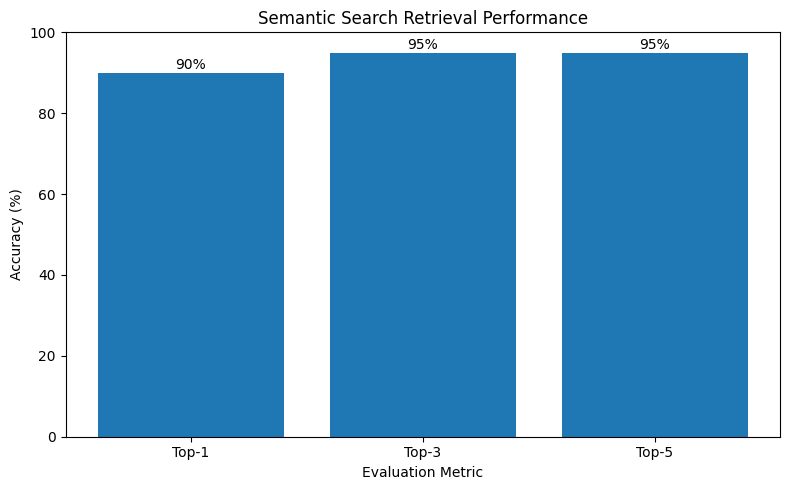

In [49]:
metrics_to_plot = {
    "Top-1": normalized_top1 * 100,
    "Top-3": normalized_top3 * 100,
    "Top-5": normalized_top5 * 100
}

plt.figure(figsize=(8, 5))

bars = plt.bar(
    metrics_to_plot.keys(),
    metrics_to_plot.values()
)

plt.title("Semantic Search Retrieval Performance")
plt.xlabel("Evaluation Metric")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)

for bar, value in zip(bars, metrics_to_plot.values()):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1,
        f"{value:.0f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

## Build a TF-IDF Keyword Search Baseline



In [50]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Create TF-IDF vectorizer
tfidf_vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english"
)

# Transform all medical questions
tfidf_matrix = tfidf_vectorizer.fit_transform(
    clean_df["question"]
)

print("TF-IDF matrix shape:", tfidf_matrix.shape)

TF-IDF matrix shape: (16359, 4580)


## Implement Keyword Search

In [52]:
def keyword_search(query, top_k=5):
    """
    Search the MedQuAD dataset using TF-IDF keyword similarity.
    """

    # Convert query into TF-IDF vector
    query_vector = tfidf_vectorizer.transform([query])

    # Calculate cosine similarity
    similarities = cosine_similarity(
        query_vector,
        tfidf_matrix
    ).flatten()

    # Get top-k indices
    top_indices = np.argsort(similarities)[::-1][:top_k]

    # Retrieve results
    results = clean_df.iloc[top_indices].copy()

    # Add similarity score
    results["similarity_score"] = similarities[top_indices]

    return results.reset_index(drop=True)

## Compare Semantic Search and Keyword Search

In [53]:
comparison_query = (
    "How would someone know that their blood pressure is dangerously high?"
)

print("QUERY:")
print(comparison_query)

print("\n" + "=" * 100)
print("SEMANTIC SEARCH")
print("=" * 100)

semantic_results = semantic_search(
    comparison_query,
    top_k=3
)

for i, row in semantic_results.iterrows():
    print(f"\nRank {i + 1}")
    print("Question:", row["question"])
    print("Focus Area:", row["focus_area"])
    print("Score:", round(row["similarity_score"], 4))


print("\n" + "=" * 100)
print("TF-IDF KEYWORD SEARCH")
print("=" * 100)

keyword_results = keyword_search(
    comparison_query,
    top_k=3
)

for i, row in keyword_results.iterrows():
    print(f"\nRank {i + 1}")
    print("Question:", row["question"])
    print("Focus Area:", row["focus_area"])
    print("Score:", round(row["similarity_score"], 4))

QUERY:
How would someone know that their blood pressure is dangerously high?

SEMANTIC SEARCH

Rank 1
Question: How to diagnose High Blood Pressure ?
Focus Area: High Blood Pressure
Score: 0.7104

Rank 2
Question: How to diagnose High Blood Pressure ?
Focus Area: High Blood Pressure
Score: 0.7104

Rank 3
Question: Who is at risk for High Blood Pressure? ?
Focus Area: High Blood Pressure
Score: 0.7062

TF-IDF KEYWORD SEARCH

Rank 1
Question: What is (are) High Blood Pressure ?
Focus Area: High Blood Pressure
Score: 0.8949

Rank 2
Question: What is (are) High Blood Pressure ?
Focus Area: High Blood Pressure
Score: 0.8949

Rank 3
Question: What is (are) High Blood Pressure ?
Focus Area: High Blood Pressure
Score: 0.8949


In [54]:
tfidf_evaluation = []

for item in robust_evaluation_queries:

    query = item["query"]
    expected_focus = normalize_focus(item["expected_focus"])

    results = keyword_search(query, top_k=5)

    retrieved_focus = [
        normalize_focus(x)
        for x in results["focus_area"]
    ]

    tfidf_evaluation.append({
        "query": query,
        "expected_focus": expected_focus,
        "top1_focus": retrieved_focus[0],
        "top3_focuses": retrieved_focus[:3],
        "top5_focuses": retrieved_focus[:5],
        "top1_match": expected_focus == retrieved_focus[0],
        "top3_match": expected_focus in retrieved_focus[:3],
        "top5_match": expected_focus in retrieved_focus[:5]
    })

tfidf_evaluation_df = pd.DataFrame(tfidf_evaluation)

tfidf_evaluation_df

,query,expected_focus,top1_focus,top3_focuses,top5_focuses,top1_match,top3_match,top5_match
0,How would someone know that their blood pressu...,high blood pressure,high blood pressure,"[high blood pressure, high blood pressure, hig...","[high blood pressure, high blood pressure, hig...",True,True,True
1,What happens in the body when a person develop...,diabetes,stiff-person syndrome,"[stiff-person syndrome, stiff person syndrome,...","[stiff-person syndrome, stiff person syndrome,...",False,False,False
2,How might someone notice changes that could in...,breast cancer,breast cancer,"[breast cancer, breast cancer, breast cancer]","[breast cancer, breast cancer, breast cancer, ...",True,True,True
3,Why does Parkinson's develop and what changes ...,parkinson's disease,,"[, parkinson disease, parkinson's disease]","[, parkinson disease, parkinson's disease, par...",False,True,True
4,How can a person recognize that they might be ...,heart attack,heart attack,"[heart attack, heart attack, heart attack]","[heart attack, heart attack, heart attack, hea...",True,True,True
5,What warning signs could tell someone that the...,stroke,rabies,"[rabies, stroke, stroke]","[rabies, stroke, stroke, stroke, stroke]",False,True,True
6,How might a person realize that they could be ...,alzheimer's disease,alzheimer's disease,"[alzheimer's disease, alzheimer's disease, alz...","[alzheimer's disease, alzheimer's disease, alz...",True,True,True
7,What changes might occur in someone who develo...,lung cancer,cancer,"[cancer, breast cancer, lung cancer]","[cancer, breast cancer, lung cancer, prostate ...",False,True,True
8,What can be done to manage unhealthy levels of...,high blood cholesterol,cholesterol,"[cholesterol, 4 steps to manage your diabetes ...","[cholesterol, 4 steps to manage your diabetes ...",False,True,True
9,How might someone notice that their bones have...,osteoporosis,glaucoma,"[glaucoma, diabetic neuropathies: the nerve da...","[glaucoma, diabetic neuropathies: the nerve da...",False,False,False


In [55]:
tfidf_top1 = tfidf_evaluation_df["top1_match"].mean()
tfidf_top3 = tfidf_evaluation_df["top3_match"].mean()
tfidf_top5 = tfidf_evaluation_df["top5_match"].mean()

print(f"TF-IDF Top-1 Accuracy: {tfidf_top1:.2%}")
print(f"TF-IDF Top-3 Accuracy: {tfidf_top3:.2%}")
print(f"TF-IDF Top-5 Accuracy: {tfidf_top5:.2%}")

TF-IDF Top-1 Accuracy: 50.00%
TF-IDF Top-3 Accuracy: 75.00%
TF-IDF Top-5 Accuracy: 80.00%


In [56]:
tfidf_rr = []

for item in robust_evaluation_queries:

    query = item["query"]
    expected_focus = normalize_focus(item["expected_focus"])

    results = keyword_search(query, top_k=5)

    retrieved_focus = [
        normalize_focus(x)
        for x in results["focus_area"]
    ]

    rr = 0

    for rank, focus in enumerate(retrieved_focus, start=1):
        if focus == expected_focus:
            rr = 1 / rank
            break

    tfidf_rr.append(rr)


tfidf_mrr = np.mean(tfidf_rr)

print(f"TF-IDF MRR: {tfidf_mrr:.4f}")

TF-IDF MRR: 0.6017


In [57]:
comparison_df = pd.DataFrame({
    "Method": [
        "TF-IDF Keyword Search",
        "Sentence-BERT + FAISS"
    ],
    "Top-1 Accuracy": [
        tfidf_top1,
        normalized_top1
    ],
    "Top-3 Accuracy": [
        tfidf_top3,
        normalized_top3
    ],
    "Top-5 Accuracy": [
        tfidf_top5,
        normalized_top5
    ],
    "MRR": [
        tfidf_mrr,
        normalized_mrr
    ]
})

comparison_df

,Method,Top-1 Accuracy,Top-3 Accuracy,Top-5 Accuracy,MRR
0,TF-IDF Keyword Search,0.5,0.75,0.80,0.601667
1,Sentence-BERT + FAISS,0.9,0.95,0.95,0.925000


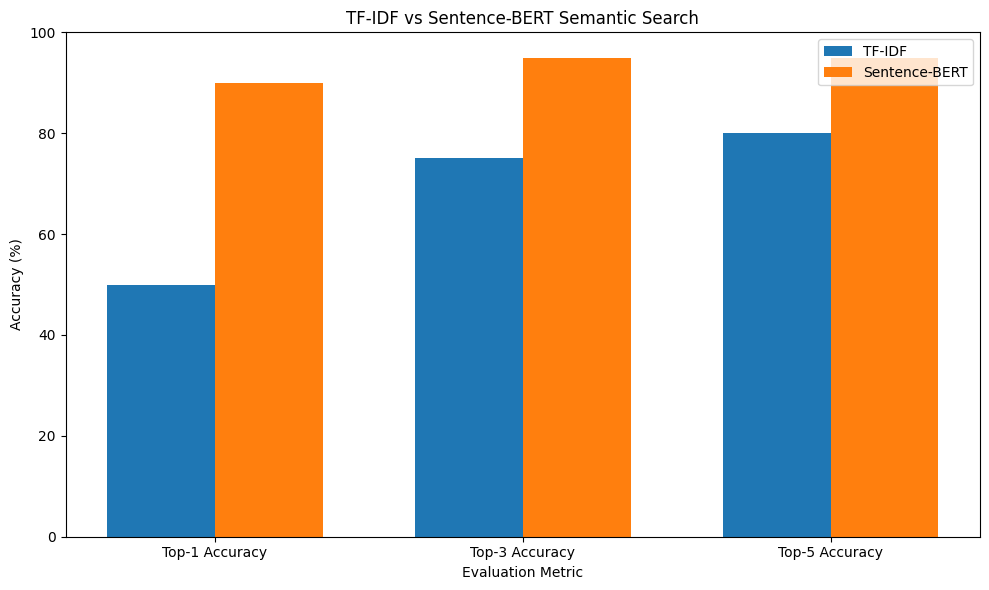

In [58]:
metrics = ["Top-1 Accuracy", "Top-3 Accuracy", "Top-5 Accuracy"]

tfidf_values = [
    tfidf_top1 * 100,
    tfidf_top3 * 100,
    tfidf_top5 * 100
]

semantic_values = [
    normalized_top1 * 100,
    normalized_top3 * 100,
    normalized_top5 * 100
]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))

plt.bar(
    x - width / 2,
    tfidf_values,
    width,
    label="TF-IDF"
)

plt.bar(
    x + width / 2,
    semantic_values,
    width,
    label="Sentence-BERT"
)

plt.xticks(x, metrics)
plt.ylabel("Accuracy (%)")
plt.xlabel("Evaluation Metric")
plt.title("TF-IDF vs Sentence-BERT Semantic Search")
plt.ylim(0, 100)
plt.legend()

plt.tight_layout()
plt.show()

# Results Interpretation

The results demonstrate a clear advantage of semantic search over traditional TF-IDF keyword retrieval on the paraphrased evaluation queries.

TF-IDF achieved a Top-1 retrieval accuracy of 50%, while Sentence-BERT achieved 90%. This indicates that semantic embeddings are substantially better at identifying the intended medical topic when the user's wording differs from the wording used in the dataset.

The difference is also visible in Top-3 and Top-5 retrieval. Sentence-BERT achieved 95% accuracy for both metrics, compared with 75% and 80% for TF-IDF respectively.

The Mean Reciprocal Rank also shows a substantial improvement, increasing from 0.6017 for TF-IDF to 0.9250 for Sentence-BERT. This indicates that relevant results are generally ranked much higher by the semantic search system.

The improvement occurs because TF-IDF primarily relies on lexical overlap between the query and stored questions, whereas Sentence-BERT generates contextual embeddings that capture semantic relationships between different expressions.

For example, a user may use terms such as "dangerously high blood pressure" while the dataset may contain a question referring to "high blood pressure" or "hypertension". Sentence-BERT can identify the semantic relationship even when the exact words do not match.

In [59]:
!pip -q install gradio

## Build the Semantic Search Interface


In [60]:
import gradio as gr

def gradio_search(query):
    if not query or not query.strip():
        return "Please enter a medical question."

    results = semantic_search(query, top_k=5)

    output = ""

    for i, row in results.iterrows():
        output += f"""
### Result {i + 1}

**Similarity Score:** {row['similarity_score']:.4f}

**Medical Topic:** {row['focus_area']}

**Source:** {row['source']}

**Question:**
{row['question']}

**Answer:**
{row['answer']}

---
"""

    return output

In [61]:
demo = gr.Interface(
    fn=gradio_search,
    inputs=gr.Textbox(
        label="Medical Question",
        placeholder="Example: How can someone recognize high blood pressure?",
        lines=3
    ),
    outputs=gr.Markdown(
        label="Semantic Search Results"
    ),
    title="MedQuAD Semantic Search",
    description=(
        "AI-powered medical FAQ search using "
        "Sentence-BERT embeddings and FAISS. "
        "Enter a question to retrieve the most "
        "semantically relevant medical FAQs."
    ),
    examples=[
        ["How can someone recognize high blood pressure?"],
        ["What warning signs might indicate a stroke?"],
        ["How might a person notice changes related to breast cancer?"],
        ["Why does Parkinson's disease develop?"]
    ],
    flagging_mode="never"
)

In [62]:
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://37820404c88e6074cd.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# Limitations

Although the semantic search system achieved strong retrieval performance, several limitations should be considered:

1. **Small evaluation set:** The final evaluation used 20 manually created paraphrased queries. A larger benchmark would provide a more statistically reliable evaluation.

2. **Focus-area based evaluation:** Retrieval relevance was evaluated using the `focus_area` field. This measures whether the correct medical topic was retrieved but does not fully evaluate whether the retrieved answer completely satisfies the user's intent.

3. **Pretrained model:** The Sentence-BERT model was used without domain-specific fine-tuning. A medical-domain embedding model could potentially improve retrieval for specialized terminology.

4. **Exact semantic retrieval:** The system retrieves existing answers from the dataset rather than generating new responses. It therefore cannot synthesize information across multiple medical sources.

5. **Dataset coverage:** The system can only retrieve information available in the MedQuAD dataset. Questions outside its coverage may produce irrelevant results.

6. **No conversational context:** Each query is treated independently. The system does not remember previous questions or maintain a conversation history.

7. **Medical safety:** The application is an educational information-retrieval prototype and should not be used for medical diagnosis, treatment decisions, or emergency situations.

#  Conclusion

This project developed an AI-powered semantic search system for medical question answering using the MedQuAD dataset.

The system uses the pretrained `all-MiniLM-L6-v2` Sentence-BERT model to convert 16,359 medical questions into 384-dimensional embeddings. These embeddings are normalized and indexed using FAISS, enabling efficient similarity-based retrieval using cosine similarity.

The final evaluation used 20 deliberately paraphrased medical queries to test semantic retrieval rather than exact keyword matching. The system achieved a **90% Top-1 retrieval accuracy, 95% Top-3 accuracy, 95% Top-5 accuracy, and an MRR of 0.9250**.

A TF-IDF keyword-search baseline was also implemented using the same evaluation queries. TF-IDF achieved **50% Top-1, 75% Top-3, 80% Top-5 accuracy, and an MRR of 0.6017**. The comparison demonstrates that semantic embeddings were substantially more effective at retrieving relevant medical information when the wording of the user query differed from the wording in the dataset.

The project demonstrates how pretrained embeddings and vector similarity search can be used to build practical NLP information-retrieval systems. The resulting system can also serve as the retrieval component of a larger Retrieval-Augmented Generation (RAG) applicatio

# Project Summary

| Component | Implementation |
|---|---|
| **Project** | AI-Powered Medical FAQ Semantic Search |
| **Track** | Option A — Semantic Search |
| **Dataset** | MedQuAD |
| **Usable Records** | 16,359 |
| **Sources** | 9 |
| **Unique Focus Areas** | 5,125 |
| **Embedding Model** | `all-MiniLM-L6-v2` |
| **Embedding Dimension** | 384 |
| **Vector Index** | FAISS `IndexFlatIP` |
| **Similarity** | Cosine Similarity |
| **Evaluation Queries** | 20 paraphrased queries |
| **Top-1 Retrieval** | **90.00%** |
| **Top-3 Retrieval** | **95.00%** |
| **Top-5 Retrieval** | **95.00%** |
| **MRR** | **0.9250** |
| **TF-IDF Top-1** | 50.00% |
| **TF-IDF Top-3** | 75.00% |
| **TF-IDF Top-5** | 80.00% |
| **TF-IDF MRR** | 0.6017 |
| **Interface** | Gradio |

In [63]:
requirements = """
pandas
numpy
matplotlib
scikit-learn
sentence-transformers
faiss-cpu
gradio
kagglehub
"""

with open("requirements.txt", "w") as f:
    f.write(requirements.strip())

print("requirements.txt created successfully.")

requirements.txt created successfully.
